<a href="https://colab.research.google.com/github/ArduinoPLUS/aicar/blob/main/AdamNesterovMomentumOpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Adam, Nesterov, Momentum Optimizer ---------- 0 -<AdamNesterovMomentumOpt.piynb>
# 상수 설정, 함수정의

import numpy as np
import matplotlib.pyplot as plt

START = 0.29               # 시작 x, --->:-0.32,  <---:0.29
LEARN_RATE = 0.04          # 학습율

BETA1 = 0.9                # 1 차 관성 계수
BETA2 = 0.999              # 2 차 관성 계수
EPSILON = 1e-8

A_val = 0.2                #
C_val = 19.0               #
D_val = 0.15               #
E_val = 0.06               #
#-------------------------------------------------------------------------------
def func(x, A=A_val, C=C_val, D=D_val, E=E_val):      # 함수 정의
    return C * (x**2 - A**2)**2 + D*x + E

def grad_func(x, A=A_val, C=C_val, D=D_val):          # 함수의 미분
    return C * 4 * x * (x**2 - A**2) + D


In [3]:
# Momentum Optimizer ------------------------- 1 -<AdamNesterovMomentumOpt.piynb>
def gd_Momentum(func, grad_func, x, learning_rate, MaxIter, BETA, verbose = False):

    velocity = 0                               # Velocity
    paths_x = [x,]                             # Store current points
    paths_v = [velocity,]                      # Store velocity

    if verbose == True:
        print('='*50)
        print(f"Ep.    x        g    velocity    f(x)")
        print(f"   {x:8.5f} {grad_func(x):8.5f} {velocity:8.5f}",
              f"{func(x):8.5f}")
        print('-'*50)
    # ==========================================================================
    for t in range(MaxIter):

        g = grad_func(x)                       # 현재 위치의 미분
        velocity = BETA * velocity + learning_rate * g  # Update velocity
        x = x - velocity                       # Update parameters
        paths_x.append(x)                      # Store current points
        paths_v.append(velocity)               # Append velocity at each step

        if verbose == True:
            print(f"{t+1:2d} {x:8.5f} {g:8.5f} {velocity:8.5f} {func(x):8.5f}")

    return np.array(paths_x), np.array(paths_v)


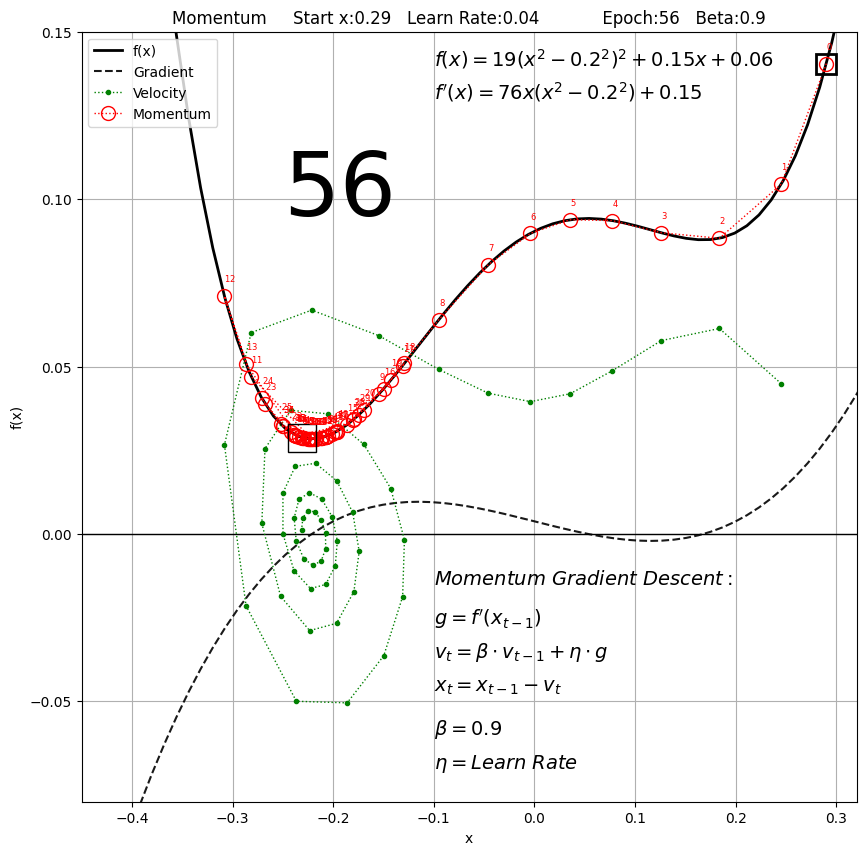

In [4]:
# Momentum Plot------------------------------- 2 -<AdamNesterovMomentumOpt.piynb>
EPOCHS = 56                                                  # 학습 회수
paths_x, paths_v = gd_Momentum(func, grad_func, START, LEARN_RATE, EPOCHS, BETA1, False)
x_plot = np.linspace(-1.2, 1.2, 200)
y_plot = func(x_plot)
# Momentum 데이터 시각화 -------------------------------------------------------
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', lw=1)                          # x = 0 에서 수평선
# 함수 f(x)
plt.plot(x_plot, y_plot, color='black', lw=2, label='f(x)')
# 미분 f'(x)
plt.plot(x_plot, grad_func(x_plot)*0.025, 'k--', alpha=0.9, label='Gradient')
# 관성 파라메터 velocity
plt.plot(paths_x[1:], paths_v[1:], 'go:', markersize=3, markeredgewidth=1,
         markerfacecolor='green', linewidth=1, label='Velocity')
# 경로 표시
plt.plot(paths_x, func(paths_x), 'ro:', markersize=10, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Momentum')
# 경로 번호
for k, x_point in enumerate(paths_x):
    y_point = func(x_point)+0.007
    plt.text(x_point, y_point, f'${k}$', verticalalignment='top', color='red',
             fontdict={'size': 6})
# x 시작 위치
plt.plot(paths_x[0], func(paths_x[0]), 'ks', markersize=14,
         markeredgewidth=2, markerfacecolor='none')
# x 마지막 위치
plt.plot(paths_x[-1], func(paths_x[-1]), 'ks', markersize=20, markerfacecolor='none')
# Legend
plt.text(-0.1, 0.140, r"$f(x) = 19(x^2-0.2^2)^2+0.15x+0.06$", fontdict={'size':14})
plt.text(-0.1, 0.130, r"$f'(x) = 76x(x^2-0.2^2)+0.15$", fontdict={'size': 14})
plt.text(-0.1, -0.015, r"$Momentum~Gradient~Descent:$", fontdict={'size': 14})
plt.text(-0.1, -0.027, r"$g = f'(x_{t-1})$", fontdict={'size':14})
plt.text(-0.1, -0.037, r"$v_{t} = \beta \cdot v_{t-1} + \eta \cdot g$", fontdict={'size':14})
plt.text(-0.1, -0.047, r"$x_{t} = x_{t-1} - v_{t}$", fontdict={'size':14})
plt.text(-0.1, -0.060, r"$\beta=0.9$", fontdict={'size': 14})
plt.text(-0.1, -0.070, r"$\eta = Learn~Rate $", fontdict={'size':14})
plt.text(-0.25, 0.095, f"{EPOCHS}", fontdict={'size': 64})     # EPOCHS
plt.legend(loc='upper left')
plt.title(f'Momentum     Start x:{START}   Learn Rate:{LEARN_RATE}\
            Epoch:{EPOCHS}   Beta:{BETA1}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.xlim(-0.45, 0.32)
plt.ylim(-0.08, 0.15)
plt.savefig(f'MOMENTUM_{EPOCHS:04d}.png')
plt.show()

In [5]:
# Nesterov Optimizer ------------------------- 3 -<AdamNesterovMomentumOpt.piynb>
def gd_Nesterov(func, grad_func, x, learning_rate, MaxIter, BETA, verbose = False):

    velocity = 0                          # Velocity

    paths_x = [x,]                        # Store current points
    paths_x_lookahead = []                # Store x_lookahead points
    paths_v = [velocity,]                 # Store velocity, initialized with 0

    if verbose == True:
        print('='*58)
        print('Ep.    x     velocity  x_lookahead g_nesterov   f(x)')
        print(f'   {x:8.5f}   {velocity:8.5f}')
        print('-'*58)
    # ==========================================================================
    for t in range(MaxIter):

        # Nesterov: Calculate gradient at the look-ahead point
        x_lookahead = x + BETA * velocity
        g_nesterov = grad_func(x_lookahead)
        # Update velocity
        velocity = BETA * velocity - LEARN_RATE * g_nesterov
        x = x + velocity
        paths_x.append(x)                      # Store current points
        paths_x_lookahead.append(x_lookahead)  # Store x_lookahead for plotting
        paths_v.append(velocity)               # Append velocity at each step
        # Update parameters

        if verbose == True:
            print(f"{t+1:2d} {x:8.5f}   {velocity:8.5f}  {x_lookahead:8.5f}",
               f"  {g_nesterov:8.5f}  {func(x):8.5f}")

    return np.array(paths_x), np.array(paths_v), np.array(paths_x_lookahead)


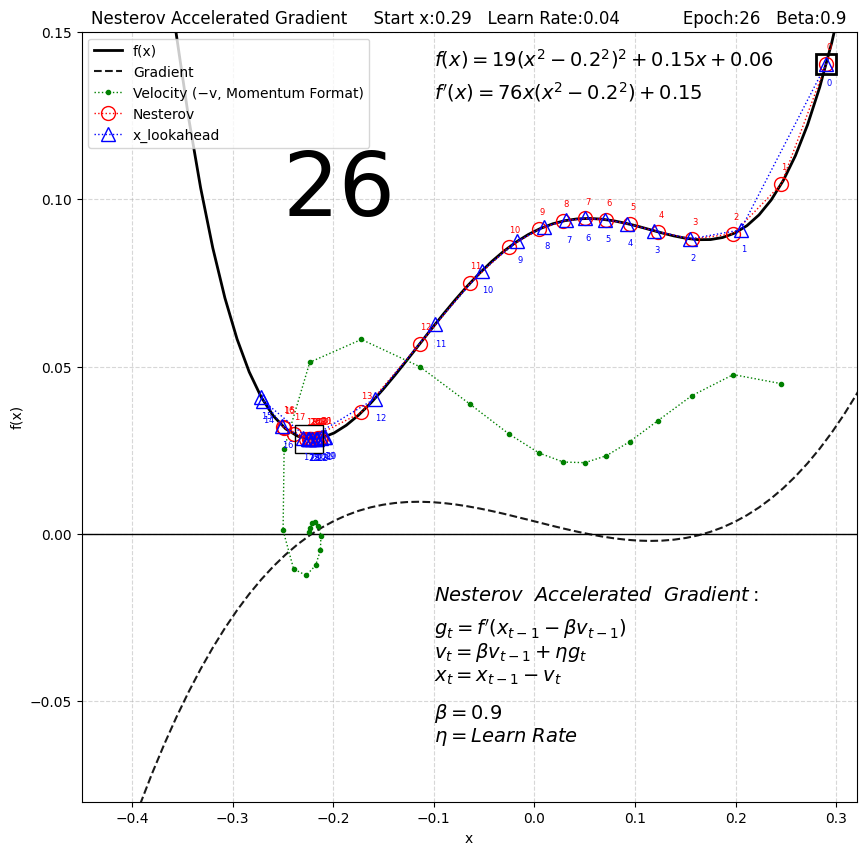

In [6]:
# Nesterov Plot ------------------------------ 4 -<AdamNesterovMomentumOpt.piynb>
EPOCHS = 26                                                  # 학습 회수
paths_x, paths_v, paths_x_lookahead = gd_Nesterov(func, grad_func, START,
                                                  LEARN_RATE, EPOCHS, BETA1, False)
x_plot = np.linspace(-1.2,1.2, 200)
y_plot = func(x_plot)
# Nesterov 데이터 시각화 -------------------------------------------------------
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', lw=1)
# 함수 f(x): 검정색 실선
plt.plot(x_plot, y_plot, color='black', lw=2, label='f(x)')
# 미분 f'(x): 검정색 대시선
plt.plot(x_plot, grad_func(x_plot)*0.025, 'k--', alpha=0.9, label='Gradient')
# 속도 velocuty: 녹색 실선 - Momentuem 의 velocity와 방향 규정이 반대이므로 부호를 반전하여 plot
plt.plot(paths_x[1:], -paths_v[1:], 'go:', markersize=3, markeredgewidth=1,
         markerfacecolor='green', linewidth=1, label='Velocity (−v, Momentum Format)')
#plt.plot(paths_x[1:], paths_v[1:],'g-',label='Velocity') # Momentum parameter
# 경로 표시 (Red): 빨간색 원형 마크
plt.plot(paths_x, func(paths_x), 'ro:', markersize=10, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Nesterov')
# x_lookahead 경로 표시 (Blue): 파란색 삼각형
plt.plot(paths_x_lookahead, func(paths_x_lookahead), 'b^:', markersize=10,
         markeredgewidth=1, markerfacecolor='none', linewidth=1, label='x_lookahead')
# 경로 번호
for k, x_point in enumerate(paths_x):
    y_point = func(x_point)+0.007
    plt.text(x_point, y_point, f'${k}$', verticalalignment='top', color='red',
             fontdict={'size': 6})
for j, x_point in enumerate(paths_x_lookahead):
    y_point = func(x_point)-0.007
    plt.text(x_point, y_point, f'${j}$', verticalalignment='bottom', color='blue',
             fontdict={'size': 6})
# x 시작 위치
plt.plot(paths_x[0], func(paths_x[0]), 'ks', markersize=14,
         markeredgewidth=2, markerfacecolor='none')
# 마지막 위치: 검정색 사각형
plt.plot(paths_x[-1], func(paths_x[-1]), 'ks', markersize=20, markerfacecolor='none')
# Legend
plt.text(-0.1,  0.140, r"$f(x) = 19(x^2-0.2^2)^2+0.15x+0.06$", fontdict={'size': 14})
plt.text(-0.1,  0.130, r"$f'(x) = 76x(x^2-0.2^2)+0.15$", fontdict={'size': 14})
plt.text(-0.1, -0.020, r"$Nesterov~~Accelerated~~Gradient:$", fontdict={'size': 14})
plt.text(-0.1, -0.030, r"$g_t = f'(x_{t-1} - \beta v_{t-1})$",fontdict={'size': 14})
plt.text(-0.1, -0.037, r"$v_{t} = \beta v_{t-1} + \eta g_t$", fontdict={'size': 14})
plt.text(-0.1, -0.044, r"$x_{t} = x_{t-1} - v_{t}$", fontdict={'size': 14})
plt.text(-0.1, -0.055, r"$\beta=0.9$",fontdict={'size': 14})
plt.text(-0.1, -0.062, r"$\eta=Learn~Rate$",fontdict={'size': 14})
plt.text(-0.25, 0.095, f"{EPOCHS}", fontdict={'size': 64})
plt.legend(loc='upper left')      # Legend
plt.title(f'Nesterov Accelerated Gradient     Start x:{START}   Learn Rate:{LEARN_RATE}\
            Epoch:{EPOCHS}   Beta:{BETA1}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.45, 0.32)
plt.ylim(-0.08, 0.15)
plt.savefig(f'NESTEROV_{EPOCHS:04d}.png')
plt.show()


In [7]:
# Adam Optimizer ----------------------------- 5 -<AdamNesterovMomentumOpt.piynb>
def gd_Adam(func, grad_func, x, learning_rate, MaxIter, BETA1, BETA2, verbose = False):

    m = 0                              # First moment
    v = 0                              # Second moment
    paths_x = [x,]                     # List to store x
    paths_m = [m,]                     # List to store first moment
    paths_v = [v,]                     # List to store second  moment
    paths_m_hat = [m,]                 #
    paths_v_hat = [v,]                 #
    paths_lr_eff = [0,]                # List to store effective learning rates
    t = 1                              # Time step

    if verbose == True:
        print('='*75)
        print(f"Ep.    x      f(x)       g        m       m_hat     v      v_hat   lr_eff")
        print('-'*75)
    # ==========================================================================
    for n in range(MaxIter):

        g = grad_func(x)

        m = BETA1 * m + (1 - BETA1) * g            # 1 차 모멘트
        v = BETA2 * v + (1 - BETA2) * g**2         # 2 차 모멘트

        m_hat = m / (1 - BETA1**t)                 # 1 차 모멘트의 바이어스 보정
        v_hat = v / (1 - BETA2**t)                 # 2 차 모멘트의 바이어스 보정

        lr_eff = learning_rate / (np.sqrt(v_hat) + EPSILON) # 실제 적용 학습율

        x = x - lr_eff * m_hat          #       # Update parameters
        paths_x.append(x)               # x
        paths_m.append(m)               # biased first moment
        paths_v.append(v)               # biased second moment
        paths_m_hat.append(m_hat)       # bias-corrected first moment
        paths_v_hat.append(v_hat)       # bias-corrected second moment
        paths_lr_eff.append(lr_eff)     # Effective Learn Rate
        t = t + 1                       # Time step

        if verbose == True:
            print(f"{n+1:2d} {x:8.5f} {func(x):8.5f} {g:8.5f}",
                  f"{m:8.5f} {m_hat:8.5f} {v:8.5f} {v_hat:8.5f}  {lr_eff:6.4f}")

    return np.array(paths_x),np.array(paths_m),np.array(paths_v),np.array(paths_m_hat),\
           np.array(paths_v_hat),np.array(paths_lr_eff)

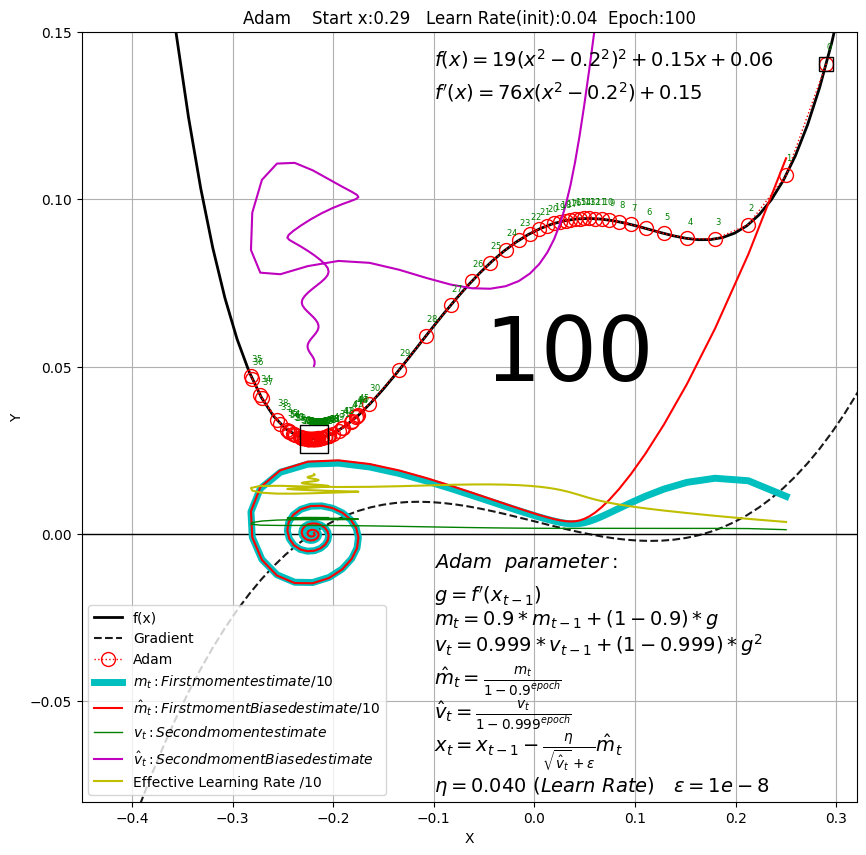

In [8]:
# Adam Optimizer Plot ------------------------ 6 -<AdamNesterovMomentumOpt.piynb>
EPOCHS = 100 # 2000   # 학습 회수
paths_x, paths_m, paths_v, paths_hat_m, paths_hat_v, lr_effective = \
             gd_Adam(func, grad_func, START, LEARN_RATE, EPOCHS, BETA1, BETA2, False)
x_plot = np.linspace(-1.2,1.2, 200)
y_plot = func(x_plot)
# Adam 데이터 시각화 -----------------------------------------------------------
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', lw=1)
# 함수 f(x)
plt.plot(x_plot, y_plot, color='black', lw=2, label='f(x)')
# 미분 f'(x)
plt.plot(x_plot, grad_func(x_plot)*0.025, 'k--', alpha=0.9, label='Gradient')
# 경로 표시
plt.plot(paths_x, func(paths_x), 'ro:', markersize=10, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Adam')
# 시작 위치
plt.plot(paths_x[0], func(paths_x[0]), 'ks', markersize=10,
         markeredgewidth=1, markerfacecolor='none')
# 마지막 위치
plt.plot(paths_x[-1], func(paths_x[-1]), 'ks', markersize=20,
         markeredgewidth=1, markerfacecolor='none')
# 경로 번호
for k, x_point in enumerate(paths_x):
    y_point = func(x_point)+0.007
    plt.text(x_point, y_point, f'${k}$', verticalalignment='top', color='green',
             fontdict={'size': 6})                                 # Adam
# Adam parameter
plt.plot(paths_x[1:], paths_m[1:]*0.1,'c-', lw=5, label=r'$m_{t}:First moment estimate /10$')
plt.plot(paths_x[1:], paths_hat_m[1:]*0.1,'r-',label=r'$\hat m_{t}:First moment Biased estimate /10$')
plt.plot(paths_x[1:], paths_v[1:],'g-',lw=1, label=r'$v_{t}:Second moment estimate$')
plt.plot(paths_x[1:], paths_hat_v[1:],'m-',label=r'$\hat v_{t}:Second moment Biased estimate$')
plt.plot(paths_x[1:], lr_effective[1:]*0.1,'y-',label='Effective Learning Rate /10')
# Legend
plt.text(-0.1, 0.140,r"$f(x) = 19(x^2-0.2^2)^2+0.15x+0.06$", fontdict={'size': 14})
plt.text(-0.1, 0.130,r"$f'(x) = 76x(x^2-0.2^2)+0.15$", fontdict={'size': 14})
plt.text(-0.1,-0.010,r"$Adam~~parameter:$", fontdict={'size': 14}) # Adam Equation
plt.text(-0.1,-0.020,r"$g=f'(x_{t-1})$", fontdict={'size': 14})
plt.text(-0.1,-0.027,r"$m_{t} = 0.9 * m_{t-1} + (1-0.9) * g$",fontdict={'size': 14})
plt.text(-0.1,-0.035,r"$v_{t} = 0.999*v_{t-1} + (1-0.999) * g^2$",fontdict={'size': 14})
plt.text(-0.1,-0.045,r"$\hat m_{t} = \frac{m_{t}}{1-0.9^{epoch}}$",fontdict={'size': 14})
plt.text(-0.1,-0.055,r"$\hat v_{t} = \frac{v_{t}}{1-0.999^{epoch}}$",fontdict={'size': 14})
plt.text(-0.1,-0.065,
         r"$x_{t} = x_{t-1}-\frac{\eta}{\sqrt{\hat v_{t}}+\epsilon} \hat m_{t} $",
         fontdict={'size': 14})
plt.text(-0.1,-0.077,rf"$\eta = {LEARN_RATE:.3f}~(Learn~Rate)~~~\epsilon=1e-8 $",fontdict={'size': 14})
plt.text(-0.05,0.046,f"{EPOCHS}", fontdict={'size': 64})
plt.legend(loc='lower left')            # Legend
plt.title(f'Adam    Start x:{START}   Learn Rate(init):{LEARN_RATE}  Epoch:{EPOCHS}')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.xlim(-0.45, 0.32)
plt.ylim(-0.08, 0.15)
plt.savefig(f'ADAM_{EPOCHS:04d}.png')
plt.show()

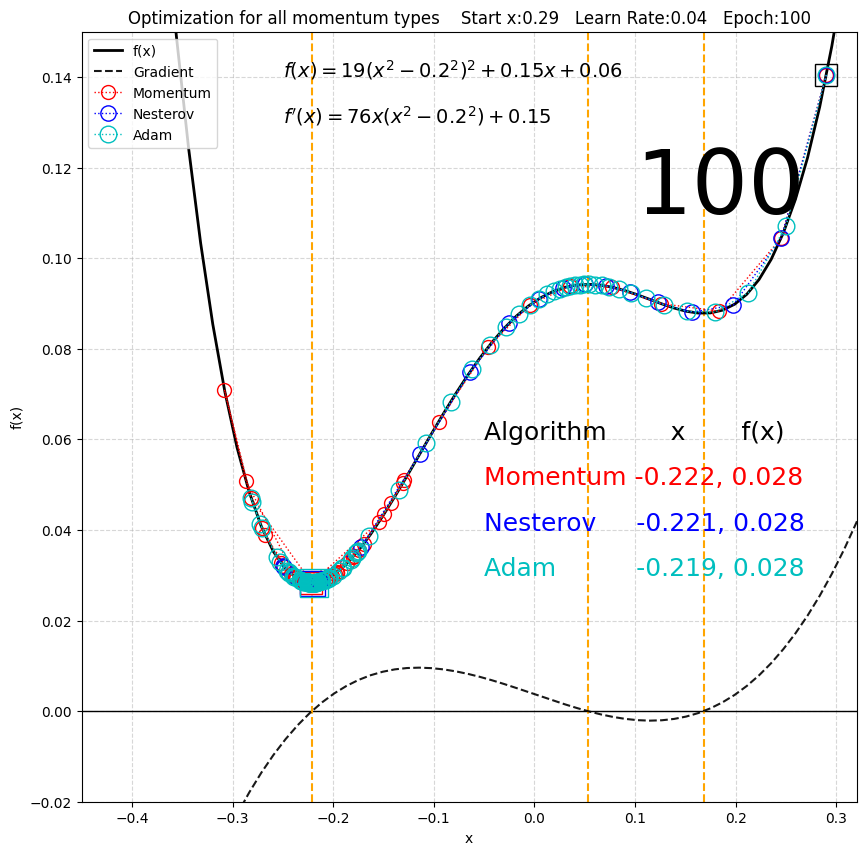

In [9]:
# Adam, Nesterov, Momentum Compare ----------- 7 -<AdamNesterovMomentumOpt.piynb>
EPOCHS = 100                                                  # 학습 회수
paths_Momentum, _ = gd_Momentum(func, grad_func, START, LEARN_RATE, EPOCHS, BETA1)
paths_Nesterov, _, _ = gd_Nesterov(func, grad_func, START, LEARN_RATE, EPOCHS, BETA1)
paths_Adam, _, _, _, _, _=gd_Adam(func, grad_func, START, LEARN_RATE, EPOCHS, BETA1, BETA2)
# Plot -------------------------------------------------------------------------
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', lw=1)
plt.axvline(x=-0.2211, color='orange', linestyle='--')
plt.axvline(x=0.0530, color='orange', linestyle='--')
plt.axvline(x=0.1681, color='orange', linestyle='--')
# 함수 f(x) --------------------------------------------------------------------
x_plot = np.linspace(-1.2,1.2, 200)
y_plot = func(x_plot)
plt.plot(x_plot, y_plot, color='black', lw=2, label='f(x)')
# 미분 f'(x)
plt.plot(x_plot, grad_func(x_plot)*0.025, 'k--', alpha=0.9, label='Gradient')
# 시작점 표시
plt.plot(START,func(START),'ks',markersize=16,markeredgewidth=1,markerfacecolor='none')
# Momentum 경로 표시 -----------------------------------------------------------
plt.plot(paths_Momentum, func(paths_Momentum), 'ro:', markersize=10, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Momentum')
plt.plot(paths_Momentum[-1], func(paths_Momentum[-1]), 'rs', markersize=16,
         markeredgewidth=1, markerfacecolor='none', linewidth=1)
# Nesterov  경로 표시 ----------------------------------------------------------
plt.plot(paths_Nesterov, func(paths_Nesterov), 'bo:', markersize=11, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Nesterov')
plt.plot(paths_Nesterov[-1], func(paths_Nesterov[-1]), 'bs', markersize=18,
         markeredgewidth=1, markerfacecolor='none', linewidth=1)
# Adam 경로 표시 ---------------------------------------------------------------
plt.plot(paths_Adam, func(paths_Adam), 'co:', markersize=12, markeredgewidth=1,
         markerfacecolor='none', linewidth=1, label='Adam')
plt.plot(paths_Adam[-1], func(paths_Adam[-1]), 'cs', markersize=20, markeredgewidth=1,
         markerfacecolor='none')
# Function, derivative function
plt.text(-0.25, 0.140, r"$f(x) = 19(x^2-0.2^2)^2+0.15x+0.06$", fontdict={'size': 14})
plt.text(-0.25, 0.130, r"$f'(x) = 76x(x^2-0.2^2)+0.15$", fontdict={'size': 14})
plt.text(0.1,  0.11, f"{EPOCHS}", fontdict={'size': 64})
plt.text(-0.05, 0.060, f"Algorithm        x       f(x)", fontdict={'size': 18})
plt.text(-0.05, 0.050, f"Momentum {paths_Momentum[-1]:6.3f},\
{func(paths_Momentum[-1]):6.3f}", fontdict={'size': 18, 'color': 'r'})
plt.text(-0.05, 0.040, f"Nesterov     {paths_Nesterov[-1]:6.3f},\
{func(paths_Nesterov[-1]):6.3f}", fontdict={'size': 18, 'color': 'b'})
plt.text(-0.05, 0.030, f"Adam          {paths_Adam[-1]:6.3f},{func(paths_Adam[-1]):6.3f}",
         fontdict={'size': 18, 'color': 'c'})
plt.legend(loc='upper left') # Legend
plt.title(f'Optimization for all momentum types    Start x:{START}   \
Learn Rate:{LEARN_RATE}   Epoch:{EPOCHS}')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-0.45, 0.32)
plt.ylim(-0.02, 0.15)
plt.savefig(f'MNA_COMP_{EPOCHS:04d}.png')
plt.show()


In [ ]:
import zipfile
import os

output_zip_filename = 'data.zip'

# Get a list of all .png files in the current directory
png_files = [f for f in os.listdir('.') if f.endswith('.png')]

if not png_files:
    print(f"No .png files found in the current directory.")
else:
    # Create a zip file and add the .png files
    with zipfile.ZipFile(output_zip_filename, 'w') as zipf:
        for png_file in png_files:
            zipf.write(png_file)
    print(f"Successfully created '{output_zip_filename}' containing {len(png_files)} .png files.")


Successfully created 'data.zip' containing 4 .png files.
